## What is active learning
Active learning trains a model with a small labeled dataset and repeatedly asks humans to label the most uncertain examples, improving the classifier efficiently



## Why Active Learning is useful for AI vs Human detection

Because:

Human labeling is expensive

Data changes over time (new AI models)

You want maximum learning from few labels

Active learning focuses annotation effort on hard examples.

Example experement

| Iteration   | Labeled Samples | Accuracy |
| ----------- | --------------- | -------- |
| Start       | 100             | 70%      |
| Iteration 1 | 200             | 78%      |
| Iteration 2 | 400             | 85%      |
| Iteration 3 | 600             | 88%      |

## Much better than random labeling.


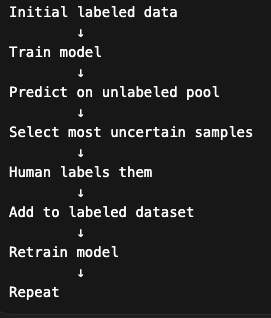

In [ ]:
!pip install scikit-learn pandas numpy

In [ ]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
#example data dummy text
data = {
    "text":[
        "Large language models generate coherent text",
        "I went hiking with my friends yesterday",
        "Neural networks learn representations from data",
        "My mother cooked pasta for dinner",
        "Transformers are powerful NLP models",
        "I watched a movie last night",
        "Deep learning models require large datasets",
        "My dog loves playing outside",
        "AI systems can summarize documents",
        "I traveled to Italy last summer"
    ],

    # 1 = AI text
    # 0 = Human text
    "label":[1,0,1,0,1,0,1,0,1,0]
}

df = pd.DataFrame(data)

In [ ]:
#In active learning we assume most data is unlabeled.
labeled_df = df.sample(4, random_state=42)
unlabeled_df = df.drop(labeled_df.index)

print("Initial labeled size:", len(labeled_df))
print("Unlabeled pool:", len(unlabeled_df))

Initial labeled size: 4
Unlabeled pool: 6


In [ ]:
#vectorization
vectorizer = TfidfVectorizer()

X_labeled = vectorizer.fit_transform(labeled_df["text"])
y_labeled = labeled_df["label"].values

X_unlabeled = vectorizer.transform(unlabeled_df["text"])

In [ ]:
#training intial model
model = LogisticRegression()

model.fit(X_labeled, y_labeled)

LogisticRegression()

# **Active Learning Step: Uncertainty Sampling**

Select samples where probability ≈ 0.5.

In [ ]:
probs = model.predict_proba(X_unlabeled)[:,1]
print(probs)
uncertainty = np.abs(probs - 0.5)
print(uncertainty)
query_index = np.argsort(uncertainty) # select 2 uncertain samples
print(query_index)
print("Selected samples for labeling:")
print(unlabeled_df.iloc[query_index]["text"])

[0.5        0.45910013 0.54089987 0.55771232 0.45910013 0.44996396]
[0.         0.04089987 0.04089987 0.05771232 0.04089987 0.05003604]
[0 1 4 2 5 3]
Selected samples for labeling:
2    Neural networks learn representations from data
3                  My mother cooked pasta for dinner
7                       My dog loves playing outside
4               Transformers are powerful NLP models
9                    I traveled to Italy last summer
6        Deep learning models require large datasets
Name: text, dtype: object


# **Simulate human labeling**

In real projects, annotators label these samples.

Here we use the known labels to simulate humans.

In [ ]:
new_samples = unlabeled_df.iloc[query_index]

labeled_df = pd.concat([labeled_df, new_samples])
unlabeled_df = unlabeled_df.drop(new_samples.index)

# Retrain the model

In [ ]:
X_labeled = vectorizer.fit_transform(labeled_df["text"])
y_labeled = labeled_df["label"].values

model.fit(X_labeled, y_labeled)

print("Updated labeled size:", len(labeled_df))
print("Remaining unlabeled:", len(unlabeled_df))

Updated labeled size: 10
Remaining unlabeled: 0


# Full Active Learning Loop

# This automates the process.

In [ ]:
for iteration in range(3):

    X_labeled = vectorizer.fit_transform(labeled_df["text"])
    y_labeled = labeled_df["label"].values

    model.fit(X_labeled, y_labeled)

    if len(unlabeled_df) == 0:
        break

    X_unlabeled = vectorizer.transform(unlabeled_df["text"])

    probs = model.predict_proba(X_unlabeled)[:,1]
    uncertainty = np.abs(probs - 0.5)

    query_index = np.argsort(uncertainty)[:2]

    new_samples = unlabeled_df.iloc[query_index]

    labeled_df = pd.concat([labeled_df, new_samples])
    unlabeled_df = unlabeled_df.drop(new_samples.index)

    print(f"Iteration {iteration+1}")
    print("New labeled size:", len(labeled_df))

# Final Evaluation

In [ ]:
X = vectorizer.fit_transform(df["text"])
y = df["label"]

pred = model.predict(X)

print(classification_report(y, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

